In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = "Y:\\jennifer\\spotiflow_mbl\\scripts\\outputs"
model_times = ["20250903_1715", "20251110_1639", "20251111_1157", "20251111_1654"]
model_names = ["Low point priority", "High point priority", "Medium point priority", "Large forward shift"]
# Create a mapping dictionary
model_name_map = dict(zip(model_times, model_names))

    
spot_stats_list = []
for model_time in model_times:
    spot_stats_path = f"Y:\\jennifer\\spotiflow_mbl\\scripts\\outputs\\spotiflow-{model_time}\\spot_stats_50ws_0.5pt.csv"
    spot_stats = pd.read_csv(spot_stats_path)
    spot_stats_list.append(spot_stats)
    spot_stats["model_time"] = model_time

spot_stats = pd.concat(spot_stats_list, ignore_index=True)

In [45]:
spot_stats.head()

,dataset,frame_window,spot_id,spot_t,spot_y,spot_x,prob,TP/FP,early_detect,dist_err_xy,spot_z,dist_err_z,model_time
0,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,5-55,0,25,923,1094,0.516121,TP,25.0,36.124784,NaN,NaN,20250903_1715
1,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,5-55,1,22,227,1052,0.514807,TP,20.0,50.990195,NaN,NaN,20250903_1715
2,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,5-55,2,24,161,223,0.512537,TP,32.0,21.540659,NaN,NaN,20250903_1715
3,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,10-60,0,25,923,1094,0.517743,TP,20.0,36.124784,NaN,NaN,20250903_1715
4,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,10-60,2,31,163,225,0.517097,TP,27.0,20.591260,NaN,NaN,20250903_1715


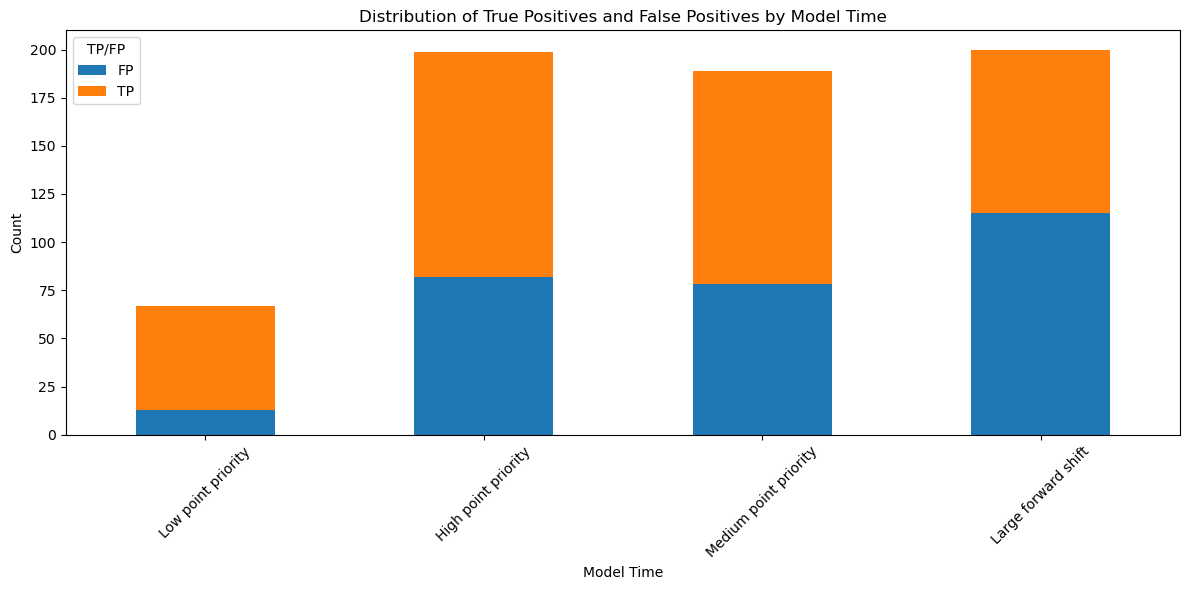

In [46]:
# make a stacked bar plot showing distribution of tps and fps for each model_time
plt.figure(figsize=(12, 6))

# Create a pivot table for stacked bar data
plot_data = spot_stats.groupby(['model_time', 'TP/FP']).size().unstack(fill_value=0)

# Create stacked bar plot
plot_data.plot(kind='bar', stacked=True, ax=plt.gca())

plt.title('Distribution of True Positives and False Positives by Model Time')
plt.xlabel('Model Time')
plt.ylabel('Count')
plt.legend(title='TP/FP')
plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()

c:\Users\hillj\AppData\Local\miniforge3\envs\spotiflow\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\hillj\AppData\Local\miniforge3\envs\spotiflow\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 50.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\hillj\AppData\Local\miniforge3\envs\spotiflow\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\4233799629.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(model_names, ro

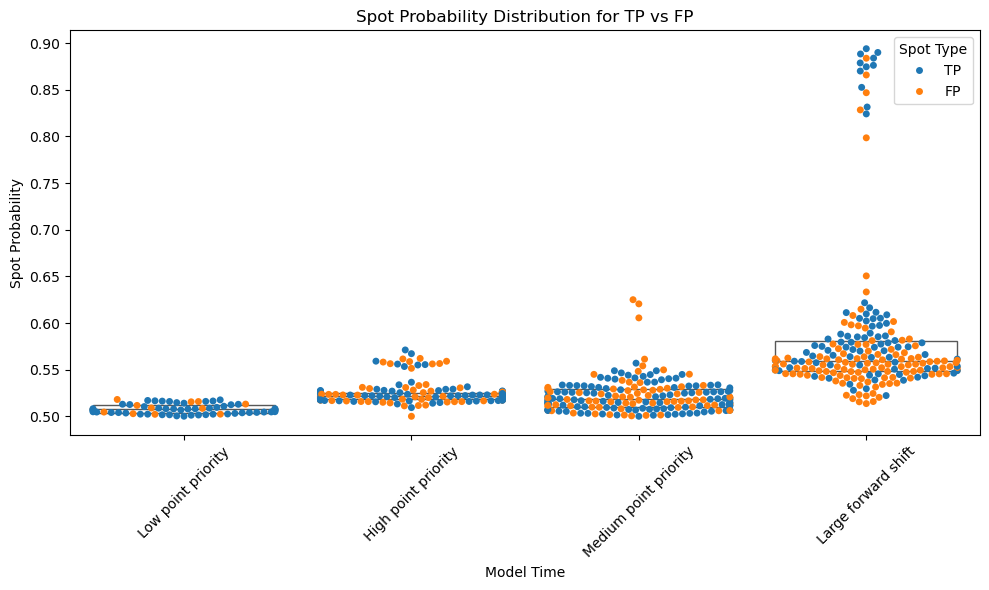

In [47]:
# make a swarm plot of prob for TP vs FP
plt.figure(figsize=(10,6))
sns.swarmplot(x='model_time', y='prob', hue='TP/FP', data=spot_stats)
plt.title('Spot Probability Distribution for TP vs FP')
# add mean lines
ax = sns.boxplot(x='model_time', y='prob', data=spot_stats,
        showcaps=False, boxprops={'facecolor':'None'},
        showfliers=False, whiskerprops={'linewidth':0}
)
plt.ylabel('Spot Probability')
plt.xlabel('Model Time')
plt.gca().set_xticklabels(model_names, rotation=45)
plt.legend(title='Spot Type')
plt.tight_layout()
plt.show()

In [48]:
# for each dataset, for each window, print tp or fp of the spot with the highest prob
# get list of unique values from spot_stats['dataset']
# Or set model_time as the index
combined_stats = pd.DataFrame(index=model_times, columns=['Top_Tps', 'Top_Fps', 'Top_TP_fraction', 'Top_FP_fraction'])
combined_stats = combined_stats.fillna(0)
for model_time in model_times:
    print(f"Analyzing model time: {model_time}")
    model_spot_stats = spot_stats[spot_stats['model_time'] == model_time]
    tps = 0
    fps = 0
    windows = 0
    datasets = model_spot_stats['dataset'].unique()
    for dataset in datasets:
        dataset_stats = model_spot_stats[model_spot_stats['dataset'] == dataset]
        frame_windows = dataset_stats['frame_window'].unique()
        for frame_window in frame_windows:
            windows += 1
            window_stats = dataset_stats[dataset_stats['frame_window'] == frame_window]
            max_prob_spot = window_stats.loc[window_stats['prob'].idxmax()]
            if max_prob_spot['TP/FP'] == "TP":
                tps += 1
            else:
                fps += 1

    combined_stats.at[model_time, 'Top_Tps'] = tps
    combined_stats.at[model_time, 'Top_Fps'] = fps
    tps_fraction = tps / windows
    fps_fraction = fps / windows
    combined_stats.at[model_time, 'Top_TP_fraction'] = tps_fraction
    combined_stats.at[model_time, 'Top_FP_fraction'] = fps_fraction
    print(f"Total TPs: {tps} ({tps_fraction:.2%}), Total FPs: {fps} ({fps_fraction:.2%})")


Analyzing model time: 20250903_1715
Total TPs: 21 (87.50%), Total FPs: 3 (12.50%)
Analyzing model time: 20251110_1639
Total TPs: 11 (44.00%), Total FPs: 14 (56.00%)
Analyzing model time: 20251111_1157
Total TPs: 13 (52.00%), Total FPs: 12 (48.00%)
Analyzing model time: 20251111_1654
Total TPs: 14 (56.00%), Total FPs: 11 (44.00%)


C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\105451963.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_stats = combined_stats.fillna(0)
C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\105451963.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.875' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_stats.at[model_time, 'Top_TP_fraction'] = tps_fraction
C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\105451963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.125' has dtype incompatible with int64, please explicitly cast to a compati

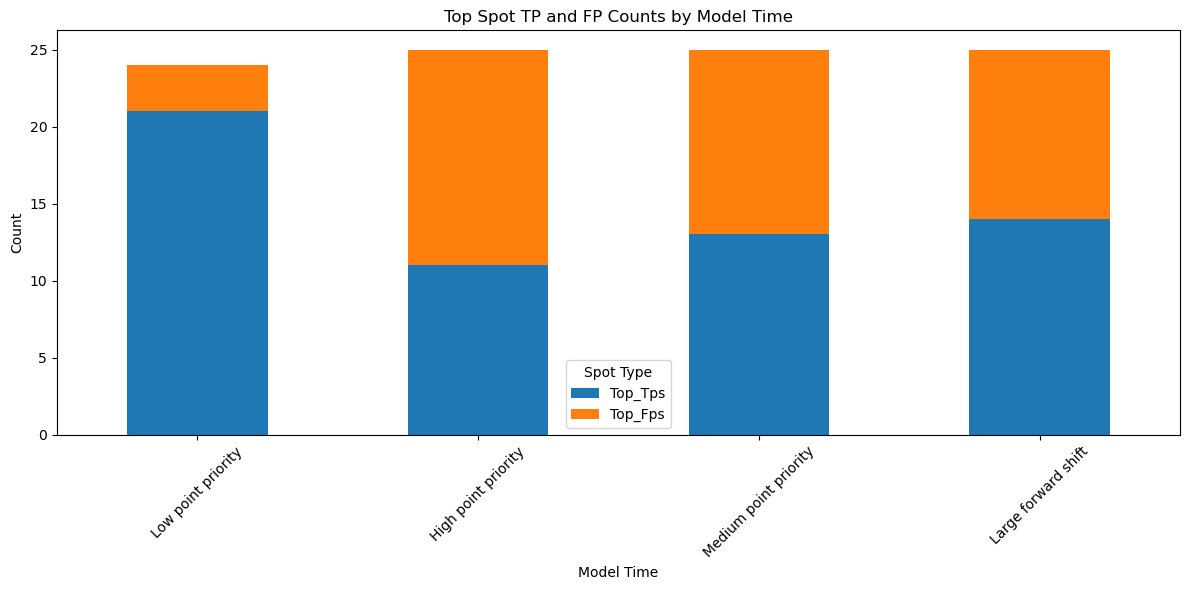

In [49]:
# Plot as stacked bar chart for each model time
plt.figure(figsize=(12, 6))
combined_stats[['Top_Tps', 'Top_Fps']].plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Top Spot TP and FP Counts by Model Time')
plt.xlabel('Model Time')
plt.ylabel('Count')
plt.legend(title='Spot Type')
plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()

In [50]:
# track spots over time
# find all unique spot ids
combined_stats = pd.DataFrame(index=model_times, columns=['transient_TPs', 'transient_FPs', 'persistent_TPs', 'persistent_FPs'])
combined_stats = combined_stats.fillna(0)

for model_time in model_times:
    print(f"Analyzing model time: {model_time}")
    model_spot_stats = spot_stats[spot_stats['model_time'] == model_time]
    tps = 0
    fps = 0
    datasets = model_spot_stats['dataset'].unique()
    transient_tps = 0
    transient_fps = 0
    persistent_tps = 0
    persistent_fps = 0
    for dataset in datasets:
        dataset_stats = model_spot_stats[model_spot_stats['dataset'] == dataset]
        spot_ids = dataset_stats['spot_id'].unique()
        for spot_id in spot_ids:
            if pd.isna(spot_id):
                continue
            spot_data = dataset_stats[dataset_stats['spot_id'] == spot_id]
            if len(spot_data) <= 1:
                if spot_data['TP/FP'].values[0] == "TP":
                    transient_tps += 1
                else:
                    transient_fps += 1
            else:
                if any(spot_data['TP/FP'] == "TP"):
                    persistent_tps += 1
                else:
                    persistent_fps += 1

    combined_stats.at[model_time, 'transient_TPs'] = transient_tps
    combined_stats.at[model_time, 'transient_FPs'] = transient_fps
    combined_stats.at[model_time, 'persistent_TPs'] = persistent_tps
    combined_stats.at[model_time, 'persistent_FPs'] = persistent_fps

    print(f"Unique Spots - Temporary TPs: {transient_tps}, Temporary FPs: {transient_fps}, Persistent TPs: {persistent_tps}, Persistent FPs: {persistent_fps}")

Analyzing model time: 20250903_1715
Unique Spots - Temporary TPs: 9, Temporary FPs: 9, Persistent TPs: 9, Persistent FPs: 0
Analyzing model time: 20251110_1639
Unique Spots - Temporary TPs: 19, Temporary FPs: 32, Persistent TPs: 16, Persistent FPs: 0
Analyzing model time: 20251111_1157
Unique Spots - Temporary TPs: 12, Temporary FPs: 28, Persistent TPs: 15, Persistent FPs: 1
Analyzing model time: 20251111_1654
Unique Spots - Temporary TPs: 21, Temporary FPs: 48, Persistent TPs: 15, Persistent FPs: 1


C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\3134819664.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_stats = combined_stats.fillna(0)


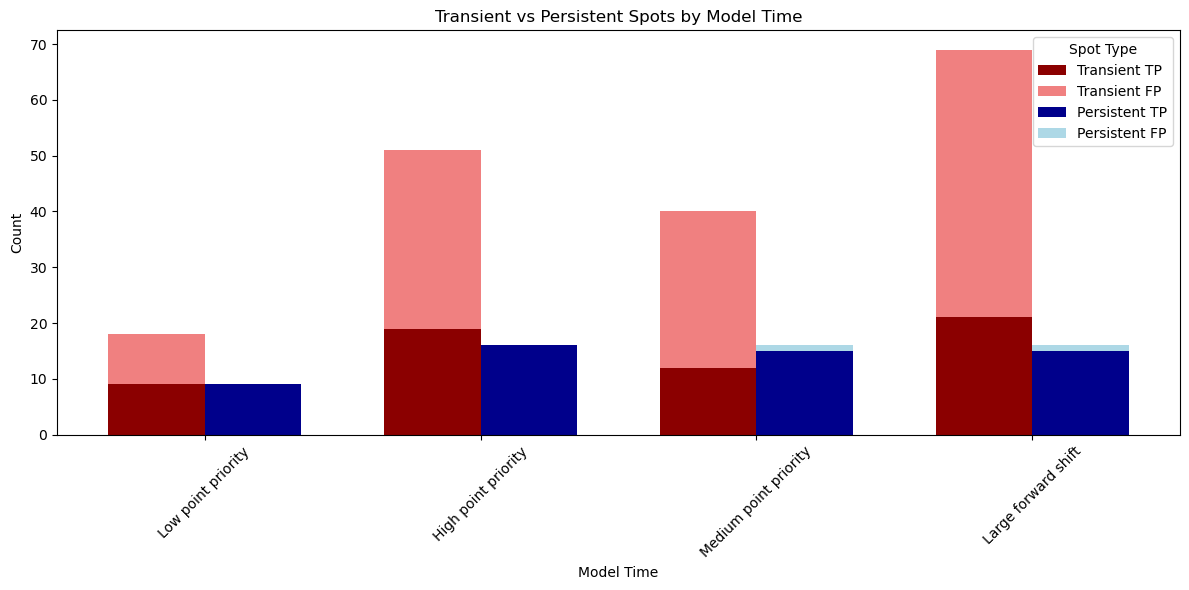

In [51]:
# plot persistent and transient spots as grouped stacked bar plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Reshape data for grouped stacked bars
x = np.arange(len(model_times))
width = 0.35

# Stack transients
tp_transient = combined_stats['transient_TPs'].values
fp_transient = combined_stats['transient_FPs'].values

# Stack persistents
tp_persistent = combined_stats['persistent_TPs'].values
fp_persistent = combined_stats['persistent_FPs'].values

# Create grouped bars
ax.bar(x - width/2, tp_transient, width, label='Transient TP', color='darkred')
ax.bar(x - width/2, fp_transient, width, bottom=tp_transient, label='Transient FP', color='lightcoral')

ax.bar(x + width/2, tp_persistent, width, label='Persistent TP', color='darkblue')
ax.bar(x + width/2, fp_persistent, width, bottom=tp_persistent, label='Persistent FP', color='lightblue')

ax.set_title('Transient vs Persistent Spots by Model Time')
ax.set_xlabel('Model Time')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)
ax.legend(title='Spot Type')

plt.tight_layout()
plt.show()

In [52]:
# TODO: plot as # of persistent frames vs TP/FP rate


In [53]:
# calc average early_detect frames and dist_err_xy for TPs
combined_stats = pd.DataFrame(index=model_times, columns=['avg_early_detect', 'avg_dist_err_xy'])
combined_stats = combined_stats.fillna(0)
for model_time in model_times:
    model_stats = spot_stats[spot_stats['model_time'] == model_time]
    tp_stats = model_stats[model_stats['TP/FP'] == "TP"]
    # filter tps with early_detect < 0
    tp_stats = tp_stats[tp_stats['early_detect'] >= 0]
    avg_early_detect = tp_stats['early_detect'].mean()
    avg_dist_error_xy = tp_stats['dist_err_xy'].mean()
    combined_stats.at[model_time, 'avg_early_detect'] = avg_early_detect
    combined_stats.at[model_time, 'avg_dist_err_xy'] = avg_dist_error_xy
    print(f"Average early detection frames for TPs: {avg_early_detect:.2f}")
    print(f"Average XY distance error for TPs: {avg_dist_error_xy:.2f} pixels")

Average early detection frames for TPs: 18.29
Average XY distance error for TPs: 25.63 pixels
Average early detection frames for TPs: 24.14
Average XY distance error for TPs: 39.94 pixels
Average early detection frames for TPs: 23.77
Average XY distance error for TPs: 34.45 pixels
Average early detection frames for TPs: 22.14
Average XY distance error for TPs: 60.97 pixels


C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\606254128.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_stats = combined_stats.fillna(0)
C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\606254128.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.285714285714285' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_stats.at[model_time, 'avg_early_detect'] = avg_early_detect
C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\606254128.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '25.625128217858386' has dtype incompatible with int64, plea

C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\3266126726.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(model_names, rotation=45)


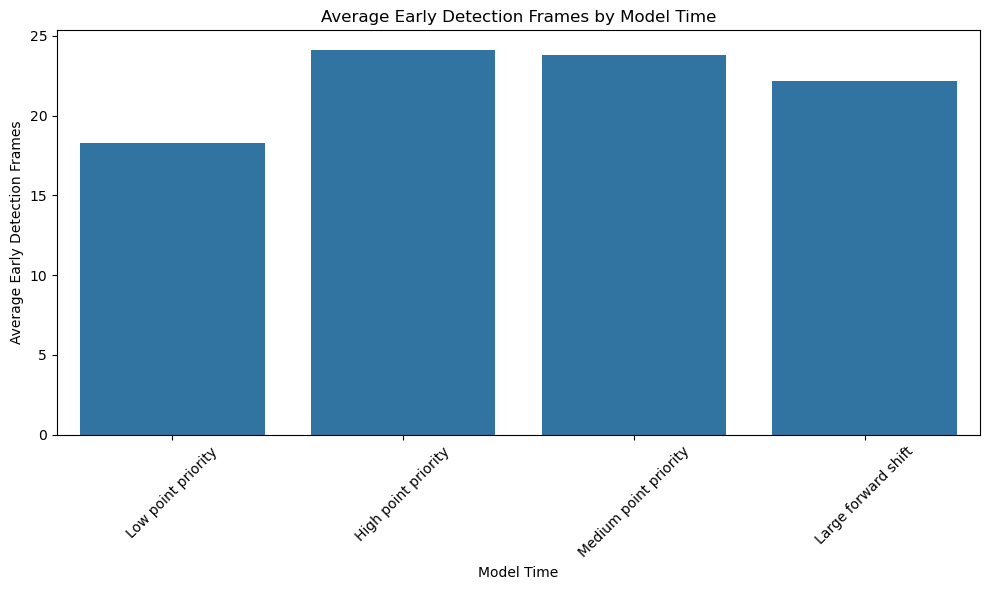

In [54]:
# Plot early detection for each model_time
plt.figure(figsize=(10,6))
sns.barplot(x=combined_stats.index, y='avg_early_detect', data=combined_stats)
plt.title('Average Early Detection Frames by Model Time')
plt.xlabel('Model Time')
plt.ylabel('Average Early Detection Frames')
plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()

C:\Users\hillj\AppData\Local\Temp\ipykernel_4024\1540982945.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(model_names, rotation=45)


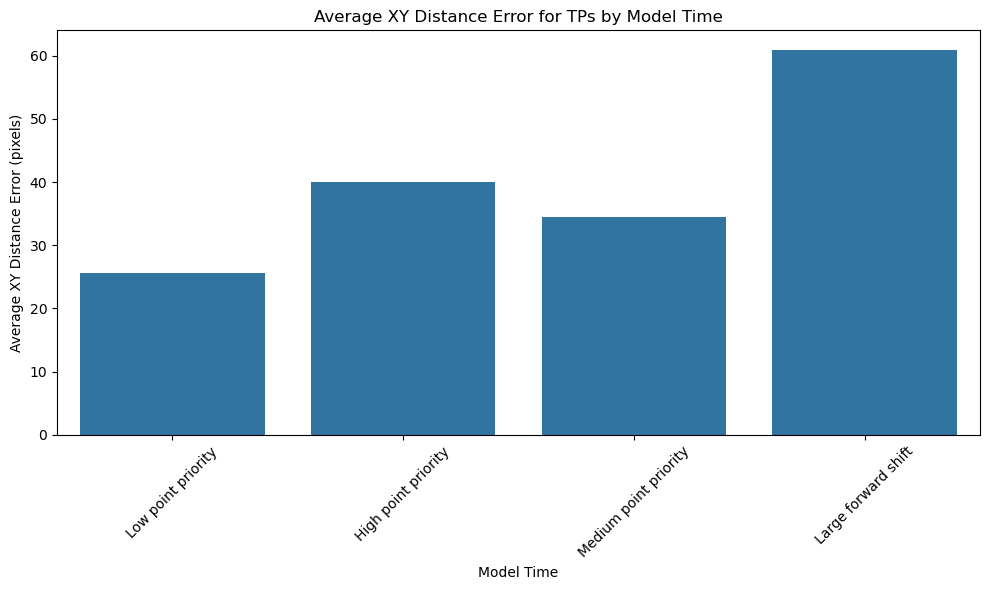

In [55]:
# Plot avg dist err xy for each model_time
plt.figure(figsize=(10,6))
sns.barplot(x=combined_stats.index, y='avg_dist_err_xy', data=combined_stats)
plt.title('Average XY Distance Error for TPs by Model Time')
plt.xlabel('Model Time')
plt.ylabel('Average XY Distance Error (pixels)')
plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()